In [2]:
#!pip install yfinance
#!pip install yfinance pandas_datareader


import pandas_datareader.data as web
from datetime import datetime, timedelta
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#Ideas for queries

#Types of client relationships:
    #asset management client

#generic
    #What are the latest drivers of market behavior, major financial/economic news?
    #What are the latest change in the performance of  SPX, NASDAQ, oil, latest values of US GDP growth, unemployment

#client-specific
    #NEWS
    
    #DATA
    #How has the client's stock performed over the past year and its competitors'?
    #What are the latest news about the client's company and its competitors?
    #How has the client's portfolio performed recently vs benchmark and drivers of that performance? (if relevant)






In [6]:
#GENERIC QUERIES

# Function to fetch data from FRED
def fetch_fred_data(series_id):
    """Fetch data from FRED by series ID."""
    data = web.DataReader(series_id, 'fred')
    return data.iloc[-1, 0]  # Get the latest value

# Correct CPI YoY calculation using CPIAUCSL level series
def fetch_cpi_yoy(_=None):  # Add dummy param so it's compatible with indicator loop
    """Calculate US CPI YoY change using CPIAUCSL level data from FRED."""
    cpi = web.DataReader('CPIAUCSL', 'fred')
    latest = cpi.iloc[-1, 0]
    year_ago = cpi.iloc[-13, 0]  # 13 months ago = same month last year
    yoy = ((latest - year_ago) / year_ago) * 100
    return round(yoy, 2)

# Function to fetch stock or commodity data from Yahoo Finance
def fetch_yf_data(ticker, period='1d', interval='1d'):
    """Fetch the latest data for a given Yahoo Finance ticker."""
    data = yf.download(ticker, period=period, interval=interval)
    return round(data['Close'].iloc[-1], 2)

# Function to calculate the 1-year percentage change from Yahoo Finance data
def fetch_yf_1yr_change(ticker):
    """Fetch 1-year percentage change for a given Yahoo Finance ticker."""
    data = yf.download(ticker, period='1y', interval='1d')
    start = data['Close'].iloc[0]
    end = data['Close'].iloc[-1]
    return round(((end - start) / start) * 100, 2)

# Define a dictionary to map indicators to their fetch functions and sources
indicators = {
    "US CPI YoY": {
        "fetch_func": fetch_cpi_yoy,
        "source": None
    },
    "US GDP Growth Rate": {
        "fetch_func": fetch_fred_data, 
        "source": 'A191RL1Q225SBEA'
    },
    "US Unemployment Rate": {
        "fetch_func": fetch_fred_data, 
        "source": 'UNRATE'
    },
    "WTI Crude Oil Price": {
        "fetch_func": fetch_yf_data, 
        "source": 'CL=F',
        "args": {'period': '1d', 'interval': '1d'}
    },
    "S&P 500 1-Year Change": {
        "fetch_func": fetch_yf_1yr_change, 
        "source": '^GSPC'
    },
    "NASDAQ 1-Year Change": {
        "fetch_func": fetch_yf_1yr_change, 
        "source": '^IXIC'
    }
}

# Fetch the data for all indicators
data = {}
for indicator, details in indicators.items():
    fetch_func = details['fetch_func']
    source = details.get('source')
    args = details.get('args', {})
    value = fetch_func(source, **args) if source else fetch_func()  # Call without source if None
    data[indicator] = value

# Organize the data into a DataFrame
df = pd.DataFrame(list(data.items()), columns=["Indicator", "Value"])
df

















YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Indicator,Value
0,US CPI YoY,2.41
1,US GDP Growth Rate,2.4
2,US Unemployment Rate,4.2
3,WTI Crude Oil Price,Ticker CL=F 61.76 Name: 2025-04-15 00:00:00...
4,S&P 500 1-Year Change,Ticker ^GSPC 6.8 dtype: float64
5,NASDAQ 1-Year Change,Ticker ^IXIC 5.96 dtype: float64


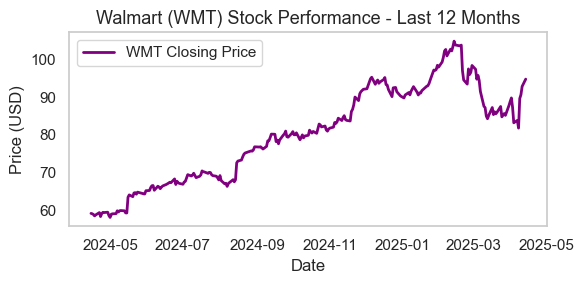

[*********************100%***********************]  1 of 1 completed
/var/folders/bs/qm6q0s4n4_s1j7khh9mkb67r0000gn/T/ipykernel_83456/1418635899.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(round(data['Close'].iloc[-1], 2))
[*********************100%***********************]  1 of 1 completed
/var/folders/bs/qm6q0s4n4_s1j7khh9mkb67r0000gn/T/ipykernel_83456/1418635899.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(round(data['Close'].iloc[-1], 2))
[*********************100%***********************]  1 of 1 completed
/var/folders/bs/qm6q0s4n4_s1j7khh9mkb67r0000gn/T/ipykernel_83456/1418635899.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(ro

,Level,1-Month Change (%),1-Year Change (%),2-Year Change (%)
Indicator,,,,
S&P 500,5405.97,-4.74,6.8,30.22
NASDAQ,16831.48,-5.49,5.96,38.44
WTI Crude Oil Price,61.76,-8.61,-27.69,-23.59
US CPI,319.62,-0.05,2.41,5.96
US Dollar Index (DXY),99.61,-3.64,-6.22,-2.44
US GDP Growth Rate,2.40,,,
US Unemployment Rate,4.20,,,
10-Year Treasury Yield,4.28,,,
Fed Funds Rate,4.33,,,


In [7]:
#CLIENT SPECIFIC QUERIES


# Set seaborn style
sns.set(style="whitegrid")

# Download recent data for Walmart (WMT)
wmt = yf.Ticker("WMT")

# Get 3 months of historical daily data
hist = wmt.history(period="12mo")

# Plot
plt.figure(figsize=(6, 3))
plt.plot(hist.index, hist['Close'], label="WMT Closing Price", color='purple', linewidth=2)
plt.title("Walmart (WMT) Stock Performance - Last 12 Months", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


# === Fetch functions ===

def fetch_fred_data(series_id):
    """Fetch latest value from FRED."""
    data = web.DataReader(series_id, 'fred')
    return round(data.iloc[-1, 0], 2)

def fetch_cpi_levels():
    """Fetch CPI levels and calculate changes."""
    cpi = web.DataReader('CPIAUCSL', 'fred')
    latest = cpi.iloc[-1, 0]
    one_month_ago = cpi.iloc[-2, 0]
    one_year_ago = cpi.iloc[-13, 0]
    two_years_ago = cpi.iloc[-25, 0]
    return {
        'level': round(latest, 2),
        '1mo': round(((latest - one_month_ago) / one_month_ago) * 100, 2),
        '1yr': round(((latest - one_year_ago) / one_year_ago) * 100, 2),
        '2yr': round(((latest - two_years_ago) / two_years_ago) * 100, 2)
    }

def fetch_yf_data(ticker, period='1d', interval='1d'):
    data = yf.download(ticker, period=period, interval=interval)
    return float(round(data['Close'].iloc[-1], 2))

def fetch_yf_change(ticker, period):
    data = yf.download(ticker, period=period, interval='1d')
    start = data['Close'].iloc[0]
    end = data['Close'].iloc[-1]
    return float(round(((end - start) / start) * 100, 2))

# === Indicators ===

indicators = {
    "S&P 500": {"fetch_func": fetch_yf_data, "source": "^GSPC"},
    "NASDAQ": {"fetch_func": fetch_yf_data, "source": "^IXIC"},
    "WTI Crude Oil Price": {"fetch_func": fetch_yf_data, "source": "CL=F"},
    "US GDP Growth Rate": {"fetch_func": fetch_fred_data, "source": "A191RL1Q225SBEA"},
    "US Unemployment Rate": {"fetch_func": fetch_fred_data, "source": "UNRATE"},
    "10-Year Treasury Yield": {"fetch_func": fetch_fred_data, "source": "GS10"},
    "Fed Funds Rate": {"fetch_func": fetch_fred_data, "source": "FEDFUNDS"},
    "US Dollar Index (DXY)": {"fetch_func": fetch_yf_data, "source": "DX-Y.NYB"},
}

# === Fetch Level Data ===

data = {}
for indicator, details in indicators.items():
    func = details["fetch_func"]
    source = details.get("source")
    value = func(source)
    data[indicator] = value

# === Fetch CPI changes ===
cpi_data = fetch_cpi_levels()

# === Fetch % changes for market indicators ===

for ticker, label in {
    "^GSPC": "S&P 500",
    "^IXIC": "NASDAQ",
    "CL=F": "WTI Crude Oil Price",
    "DX-Y.NYB": "US Dollar Index (DXY)"
}.items():
    data[f"{label} 1-Month Change (%)"] = fetch_yf_change(ticker, '1mo')
    data[f"{label} 1-Year Change (%)"] = fetch_yf_change(ticker, '1y')
    data[f"{label} 2-Year Change (%)"] = fetch_yf_change(ticker, '2y')

# === Build final DataFrame ===

df_final = pd.DataFrame({
    'Indicator': [
        'S&P 500',
        'NASDAQ',
        'WTI Crude Oil Price',
        'US CPI',
        'US Dollar Index (DXY)',
        'US GDP Growth Rate',
        'US Unemployment Rate',
        '10-Year Treasury Yield',
        'Fed Funds Rate'
    ],
    'Level': [
        data['S&P 500'],
        data['NASDAQ'],
        data['WTI Crude Oil Price'],
        cpi_data['level'],
        data['US Dollar Index (DXY)'],
        data['US GDP Growth Rate'],
        data['US Unemployment Rate'],
        data['10-Year Treasury Yield'],
        data['Fed Funds Rate']
    ],
    '1-Month Change (%)': [
        data['S&P 500 1-Month Change (%)'],
        data['NASDAQ 1-Month Change (%)'],
        data['WTI Crude Oil Price 1-Month Change (%)'],
        cpi_data['1mo'],
        data['US Dollar Index (DXY) 1-Month Change (%)'],
        '', '', '', ''
    ],
    '1-Year Change (%)': [
        data['S&P 500 1-Year Change (%)'],
        data['NASDAQ 1-Year Change (%)'],
        data['WTI Crude Oil Price 1-Year Change (%)'],
        cpi_data['1yr'],
        data['US Dollar Index (DXY) 1-Year Change (%)'],
        '', '', '', ''
    ],
    '2-Year Change (%)': [
        data['S&P 500 2-Year Change (%)'],
        data['NASDAQ 2-Year Change (%)'],
        data['WTI Crude Oil Price 2-Year Change (%)'],
        cpi_data['2yr'],
        data['US Dollar Index (DXY) 2-Year Change (%)'],
        '', '', '', ''
    ]
})

df_final.set_index('Indicator', inplace=True)
df_final



In [5]:
import feedparser

# RSS feed for top financial news
rss_url = 'https://finance.yahoo.com/news/rssindex'

# Parse the feed
feed = feedparser.parse(rss_url)

# Print headlines
for entry in feed.entries[:10]:
    print(f"Title: {entry.title}")
    print(f"Published: {entry.published}")
    print(f"Link: {entry.link}\n")


Title: Stock Market Today: Dow Jones Up As Fed's Waller Says This On Rate Cuts; Trump Wants To 'Help' Autos But Tesla Lags (Live Coverage)
Published: 2025-04-14T20:27:18Z
Link: https://www.investors.com/market-trend/stock-market-today/stock-market-today-dow-jones-sp500-nasdaq-trump-tariffs-palantir-apple-pltr-aapl/?src=A00220&yptr=yahoo

Title: Ramit Sethi: How To Become Rich on a Low Salary
Published: 2025-04-13T17:01:08Z
Link: https://finance.yahoo.com/news/ramit-sethi-become-rich-low-230052378.html

Title: Amazon.com (AMZN) Bets $8B on Anthropic, Expands AI in AWS & Shopping
Published: 2025-04-13T17:57:59Z
Link: https://finance.yahoo.com/news/amazon-com-amzn-bets-8b-175759088.html

Title: Apple (AAPL) Faces 28% EPS Hit Amid Tariff Fears Despite AI Rollout
Published: 2025-04-13T17:58:57Z
Link: https://finance.yahoo.com/news/apple-aapl-faces-28-eps-175857142.html

Title: Broadcom (AVGO) Sees 2025 Growth from AI Chips, VMware, Buybacks
Published: 2025-04-13T17:59:57Z
Link: https://fina